## UMAP `n_components` Ablation (all 10 categories, both content types)

Full-coverage version of the earlier 5-category, abstracts-only ablation.
Sweeps `n_components` in the same UMAP -> HDBSCAN configuration used by the
main BERTopic pipeline, for every category and both `abstracts` and
`pdf_chunks`, using the same `text-embedding-3-small` precomputed embeddings.

Output:
- `umap_ncomponents_ablation_full.csv` -- one row per (category, corpus_type, n_components),
  same columns as the original 5-category file (`category, n_components, trustworthiness,
  n_clusters, n_noise, noise_pct, silhouette`) plus a `corpus_type` column.
- `umap_ncomponents_ablation_summary.png` -- seaborn summary figure (the single plot meant
  to accompany the CSV in the paper).

Both are uploaded back to the shared Hub repo under `umap_ablation/`, matching the existing
file's location.


### Install dependencies (Colab only, skip if already installed locally)

In [1]:
# Uncomment if running in Colab or a fresh environment
!pip install umap-learn hdbscan scikit-learn huggingface_hub seaborn matplotlib pandas -q


### Configuration

In [2]:
import os

# --- Hugging Face repo (shared corpus) ---
REPO_ID = "Sakhiur/empirical-rag-paradigm-benchmark"
REPO_TYPE = "dataset"

# --- Which model's embeddings to use ---
EMBEDDING_MODEL = "text-embedding-3-small"

# --- The 10 target categories ---
ALL_CATEGORIES = [
    "cs.AI", "cs.LG", "cs.IR", "cs.DB", "cs.SE",       # researcher 1
    "cs.CV", "cs.CL", "cs.NE", "cs.DC", "cs.CR",       # researcher 2
]
CONTENT_TYPES = ["abstracts", "pdf_chunks"]

# --- n_components sweep (fixed n_neighbors/min_dist, matching the main BERTopic pipeline) ---
N_COMPONENTS_GRID = [2, 5, 10, 15, 20]
UMAP_N_NEIGHBORS = 15   # BERTopic default, held fixed -- this ablation isolates n_components only
UMAP_MIN_DIST = 0.0     # BERTopic default

# --- HDBSCAN settings (held fixed, matching the main BERTopic pipeline) ---
HDBSCAN_MIN_CLUSTER_SIZE = 10

# --- Reproducibility ---
RANDOM_STATE = 42

# --- Local paths ---
PROJECT_ROOT = ".."
ABLATION_DIR = os.path.join(PROJECT_ROOT, "data", "umap_ablation")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "results", "figures", "umap_ablation")
os.makedirs(ABLATION_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

CSV_PATH = os.path.join(ABLATION_DIR, "umap_ncomponents_ablation_full.csv")
SUMMARY_FIG_PATH = os.path.join(FIGURES_DIR, "umap_ncomponents_ablation_summary.png")

FORCE_RECOMPUTE = False


### Authenticate with Hugging Face

In [3]:
from huggingface_hub import whoami, login

try:
    user_info = whoami()
    print(f"Authenticated as: {user_info['name']}")
except Exception:
    print("Not authenticated yet, prompting for token...")
    login()
    user_info = whoami()
    print(f"Authenticated as: {user_info['name']}")


Authenticated as: Sakhiur


### Loader functions

Same join pattern as `bertopic_modeling.ipynb`: embeddings and source records are loaded
separately and joined on `chunk_id`. Only the embedding vectors are needed for this ablation
(no text is required, since trustworthiness/silhouette/noise are computed purely on the
embedding geometry), but `load_embeddings` is kept identical to the main pipeline's version
for consistency.

In [4]:
import json
import numpy as np
from huggingface_hub import hf_hub_download

def load_embeddings(category: str, corpus_type: str) -> dict[str, list[float]]:
    repo_path = f"embeddings/{EMBEDDING_MODEL}/{corpus_type}/{category}.jsonl"
    try:
        local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    except Exception as e:
        print(f"  [SKIP] {repo_path} not found on Hub ({e})")
        return {}
    result = {}
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            result[record["chunk_id"]] = record["embedding"]
    return result


### Ablation metric functions

Three metrics per (category, corpus_type, n_components):

- **Trustworthiness** (`sklearn.manifold.trustworthiness`): measures how well the reduced
  n_components-dimensional embedding preserves the local neighborhood structure of the
  original high-dimensional space. Range [0, 1], higher is better; a low value means UMAP
  distorted local neighborhoods at that dimensionality.
- **HDBSCAN cluster count / noise count / noise percentage**: HDBSCAN is run on the reduced
  embedding with the same `min_cluster_size` used by the main pipeline, so `n_clusters` and
  `noise_pct` are directly comparable to the final BERTopic configuration's outlier behavior.
- **Silhouette score** (`sklearn.metrics.silhouette_score`): computed on the reduced embedding
  using the HDBSCAN labels, excluding noise points. Range [-1, 1], higher indicates better
  cluster separation. Undefined (skipped) if fewer than 2 non-noise clusters are found.

Trustworthiness is capped at min(n_samples, 500) neighbors internally by sklearn's default;
for very large categories this is left at the library default rather than tuned, since the
ablation's purpose is relative comparison across n_components, not an absolute trustworthiness
benchmark.

In [5]:
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from umap import UMAP
from hdbscan import HDBSCAN

def run_ablation_point(vectors: np.ndarray, n_components: int) -> dict:
    reducer = UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        n_components=n_components,
        min_dist=UMAP_MIN_DIST,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    reduced = reducer.fit_transform(vectors)

    trust = trustworthiness(vectors, reduced, metric="cosine")

    clusterer = HDBSCAN(
        min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
        metric="euclidean",
        cluster_selection_method="eom",
    )
    labels = clusterer.fit_predict(reduced)

    n_noise = int(np.sum(labels == -1))
    unique_clusters = set(labels) - {-1}
    n_clusters = len(unique_clusters)
    noise_pct = 100 * n_noise / len(labels) if len(labels) else 0.0

    sil = float("nan")
    if n_clusters >= 2:
        non_noise_mask = labels != -1
        if non_noise_mask.sum() >= 2:
            sil = silhouette_score(reduced[non_noise_mask], labels[non_noise_mask])

    return {
        "trustworthiness": float(trust),
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_pct": float(noise_pct),
        "silhouette": sil,
    }


### Run the full sweep

Iterates every (category, corpus_type, n_components) combination. Categories with fewer than
`2 * HDBSCAN_MIN_CLUSTER_SIZE` documents are skipped, matching the skip condition used
elsewhere in the pipeline (BERTopic modeling notebook), since HDBSCAN cannot form meaningful
clusters below that size regardless of n_components.

Resumable: if `CSV_PATH` already exists and `FORCE_RECOMPUTE` is `False`, already-completed
(category, corpus_type, n_components) rows are skipped rather than recomputed.

In [6]:
import pandas as pd

if os.path.exists(CSV_PATH) and not FORCE_RECOMPUTE:
    existing_df = pd.read_csv(CSV_PATH)
    done_keys = set(zip(existing_df["category"], existing_df["corpus_type"], existing_df["n_components"]))
    print(f"Resuming: {len(done_keys)} rows already completed in {CSV_PATH}")
else:
    existing_df = pd.DataFrame(columns=["category", "corpus_type", "n_components",
                                         "trustworthiness", "n_clusters", "n_noise",
                                         "noise_pct", "silhouette"])
    done_keys = set()

rows = list(existing_df.to_dict("records"))
embeddings_cache: dict[tuple[str, str], np.ndarray] = {}

for corpus_type in CONTENT_TYPES:
    for category in ALL_CATEGORIES:
        cache_key = (category, corpus_type)
        if cache_key not in embeddings_cache:
            embeddings_dict = load_embeddings(category, corpus_type)
            if not embeddings_dict:
                print(f"[SKIP] {corpus_type}/{category}: no embeddings on Hub")
                embeddings_cache[cache_key] = None
                continue
            vectors = np.array(list(embeddings_dict.values()), dtype=np.float32)
            if len(vectors) < HDBSCAN_MIN_CLUSTER_SIZE * 2:
                print(f"[SKIP] {corpus_type}/{category}: only {len(vectors)} chunks, too few for meaningful topics")
                embeddings_cache[cache_key] = None
                continue
            embeddings_cache[cache_key] = vectors
            print(f"[LOAD] {corpus_type}/{category}: {len(vectors)} vectors, dim={vectors.shape[1]}")

        vectors = embeddings_cache[cache_key]
        if vectors is None:
            continue

        for n_components in N_COMPONENTS_GRID:
            key = (category, corpus_type, n_components)
            if key in done_keys:
                continue
            print(f"  n_components={n_components} ...", end=" ")
            metrics = run_ablation_point(vectors, n_components)
            print(f"trust={metrics['trustworthiness']:.3f}  "
                  f"n_clusters={metrics['n_clusters']}  "
                  f"noise_pct={metrics['noise_pct']:.1f}%  "
                  f"silhouette={metrics['silhouette']:.3f}")
            rows.append({
                "category": category,
                "corpus_type": corpus_type,
                "n_components": n_components,
                **metrics,
            })
            # write after every point so a long run is resumable, not just resumable per-category
            pd.DataFrame(rows).to_csv(CSV_PATH, index=False)

ablation_df = pd.DataFrame(rows)
print(f"\nTotal rows: {len(ablation_df)}")
print(f"Saved to: {CSV_PATH}")


embeddings/text-embedding-3-small/abstra(…): reconstructing file:   0%|          |  0.00B /  229MB            

embeddings/text-embedding-3-small/abstra(…): downloading bytes:           |  0.00B            

[LOAD] abstracts/cs.AI: 7369 vectors, dim=1536
  n_components=2 ... 

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


trust=0.925  n_clusters=122  noise_pct=31.4%  silhouette=0.531
  n_components=5 ... 

...

trust=0.993  n_clusters=67  noise_pct=8.6%  silhouette=0.815
  n_components=15 ... 

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


trust=0.993  n_clusters=67  noise_pct=7.8%  silhouette=0.813
  n_components=20 ... 

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


trust=0.994  n_clusters=67  noise_pct=8.6%  silhouette=0.813

Total rows: 100
Saved to: ../data/umap_ablation/umap_ncomponents_ablation_full.csv


### Seaborn summary figure

One figure, meant to stand in as the paper's single summary of this ablation (replacing the
per-category numeric table for visual inspection). Two panels, sharing the x-axis
(`n_components`):

- **Left**: trustworthiness vs. `n_components`, one line per category, faceted by
  `corpus_type` via linestyle. Shows whether reconstruction quality keeps improving with
  higher dimensionality or plateaus (the usual justification for picking a specific
  `n_components`).
- **Right**: noise percentage vs. `n_components`, same faceting. Shows the outlier-rate
  cost of each dimensionality choice, which is the quantity Section on cluster validation
  in the paper actually reports per category.

A vertical reference line marks `n_components=5`, the value used by the main BERTopic
pipeline, so the figure directly shows what that choice cost/gained relative to the rest
of the swept range.

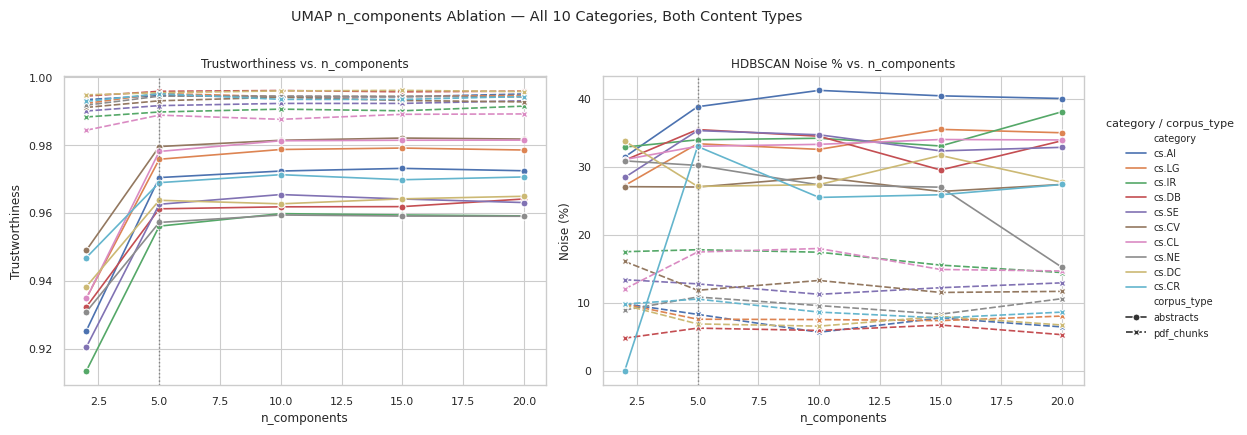

Saved ../results/figures/umap_ablation/umap_ncomponents_ablation_summary.png


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
plot_df = ablation_df.copy()
plot_df["corpus_type"] = pd.Categorical(plot_df["corpus_type"], categories=CONTENT_TYPES)

sns.lineplot(
    data=plot_df, x="n_components", y="trustworthiness",
    hue="category", style="corpus_type", markers=True, dashes=True,
    ax=axes[0], legend=False, linewidth=1.2, markersize=5,
)
axes[0].axvline(5, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Trustworthiness vs. n_components")
axes[0].set_xlabel("n_components")
axes[0].set_ylabel("Trustworthiness")

sns.lineplot(
    data=plot_df, x="n_components", y="noise_pct",
    hue="category", style="corpus_type", markers=True, dashes=True,
    ax=axes[1], linewidth=1.2, markersize=5,
)
axes[1].axvline(5, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("HDBSCAN Noise % vs. n_components")
axes[1].set_xlabel("n_components")
axes[1].set_ylabel("Noise (%)")

handles, labels = axes[1].get_legend_handles_labels()
axes[1].get_legend().remove()
fig.legend(
    handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
    fontsize=7, title="category / corpus_type", title_fontsize=8, frameon=False,
)

fig.suptitle("UMAP n_components Ablation — All 10 Categories, Both Content Types", y=1.02)
fig.tight_layout()
fig.savefig(SUMMARY_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {SUMMARY_FIG_PATH}")


### Upload CSV and figure back to Hugging Face

Uploaded to the same `umap_ablation/` path as the original 5-category file, under new
filenames (`_full` / `_summary`) so the earlier file is not overwritten and both remain
available for comparison.

In [8]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj=CSV_PATH,
    path_in_repo="umap_ablation/umap_ncomponents_ablation_full.csv",
    repo_id=REPO_ID,
    repo_type=REPO_TYPE,
    commit_message=f"Upload full 10-category UMAP n_components ablation CSV (by {user_info['name']})",
)
print("Uploaded umap_ablation/umap_ncomponents_ablation_full.csv")

api.upload_file(
    path_or_fileobj=SUMMARY_FIG_PATH,
    path_in_repo="umap_ablation/umap_ncomponents_ablation_summary.png",
    repo_id=REPO_ID,
    repo_type=REPO_TYPE,
    commit_message=f"Upload UMAP ablation summary figure (by {user_info['name']})",
)
print("Uploaded umap_ablation/umap_ncomponents_ablation_summary.png")


Uploaded umap_ablation/umap_ncomponents_ablation_full.csv


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ents_ablation_summary.png: 100%|##########|  520kB /  520kB            

Uploaded umap_ablation/umap_ncomponents_ablation_summary.png


### Summary

Row count per (corpus_type, category), for a quick sanity check that every expected
combination completed before this is cited in the paper.

In [9]:
expected = len(CONTENT_TYPES) * len(ALL_CATEGORIES) * len(N_COMPONENTS_GRID)
print(f"Expected rows: {expected}")
print(f"Actual rows:   {len(ablation_df)}")

if len(ablation_df) < expected:
    completed = set(zip(ablation_df["category"], ablation_df["corpus_type"], ablation_df["n_components"]))
    all_expected = {
        (cat, ct, nc)
        for ct in CONTENT_TYPES for cat in ALL_CATEGORIES for nc in N_COMPONENTS_GRID
    }
    missing = sorted(all_expected - completed)
    print(f"\nMissing ({len(missing)}):")
    for m in missing:
        print(f"  {m}")
else:
    print("\nAll combinations completed.")

print(ablation_df.groupby(["corpus_type", "category"]).size().rename("n_rows"))


Expected rows: 100
Actual rows:   100

All combinations completed.
corpus_type  category
abstracts    cs.AI       5
             cs.CL       5
             cs.CR       5
             cs.CV       5
             cs.DB       5
             cs.DC       5
             cs.IR       5
             cs.LG       5
             cs.NE       5
             cs.SE       5
pdf_chunks   cs.AI       5
             cs.CL       5
             cs.CR       5
             cs.CV       5
             cs.DB       5
             cs.DC       5
             cs.IR       5
             cs.LG       5
             cs.NE       5
             cs.SE       5
Name: n_rows, dtype: int64
